# **PZS Seminární práce I**
Pribanová Johana

In [27]:
from wfdb import rdsamp, rdrecord, rdann, plot_wfdb, dl_database, rdann, get_record_list, rdsamp
from scipy.io.wavfile import write
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, convolve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from matplotlib.lines import Line2D

### **1) Výpočet tepové frekvence z EKG signálu**

In [25]:
def find_bpm(ekg_signal):
  fs = record.fs
  time = (np.arange(ekg_signal.shape[0]) / fs)
  threshold = np.median(ekg_signal) + 2
  nevalidni_hodnoty = np.where(ekg_signal > threshold)[0]

  if (len(nevalidni_hodnoty) > 0):
    zacatek_nevalidnich = nevalidni_hodnoty[0]
    ekg_signal = ekg_signal[: zacatek_nevalidnich]
    time = np.arange(ekg_signal.shape[0]) / fs

  plt.figure(figsize=(15, 5))
  plt.xlabel("cas v sekundach")
  plt.ylabel("signal")
  plt.grid(True)

  sigma = 0.05 * fs
  smooth_ekg = gaussian_filter1d(ekg_signal, sigma)
  signal_baseline = np.nanpercentile(smooth_ekg, 50)
  signal_max = np.nanpercentile(smooth_ekg, 99)
  signal_range = signal_max - signal_baseline
  prominence = signal_range * 0.05
  peak_indices, _ = find_peaks(
      smooth_ekg,
      prominence=prominence,
      distance=fs * 0.4
  )
  peak_times = peak_indices / fs
  peak_amplitudes = smooth_ekg[peak_indices]

  plt.plot(
  peak_times,
  peak_amplitudes,
  "o",
  markerfacecolor="none",
  markeredgecolor="black",
  markersize=8,
  )

  plt.plot(time, smooth_ekg, color="red")
  plt.title(f"ekg signal {record.record_name} tepova frekvence = {len(peak_indices)}bpm")
  plt.show()

  return len(peak_indices)



In [11]:
record_names = get_record_list("drivedb")

limit = 60 * 31
ekg_records = []

for name in record_names:
  ekg_records.append(rdrecord(name, pn_dir="drivedb", sampto=limit))

15.5


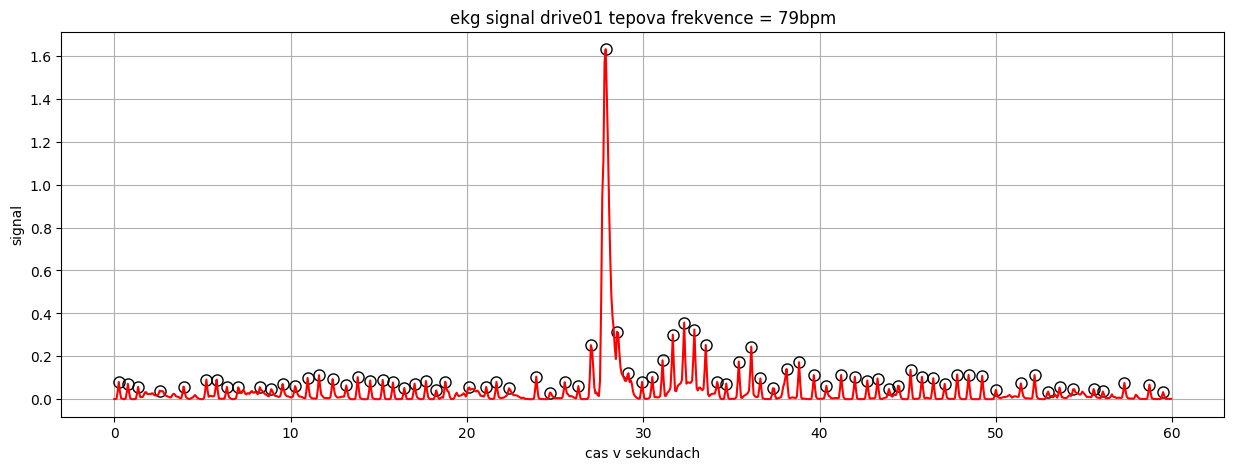

15.5


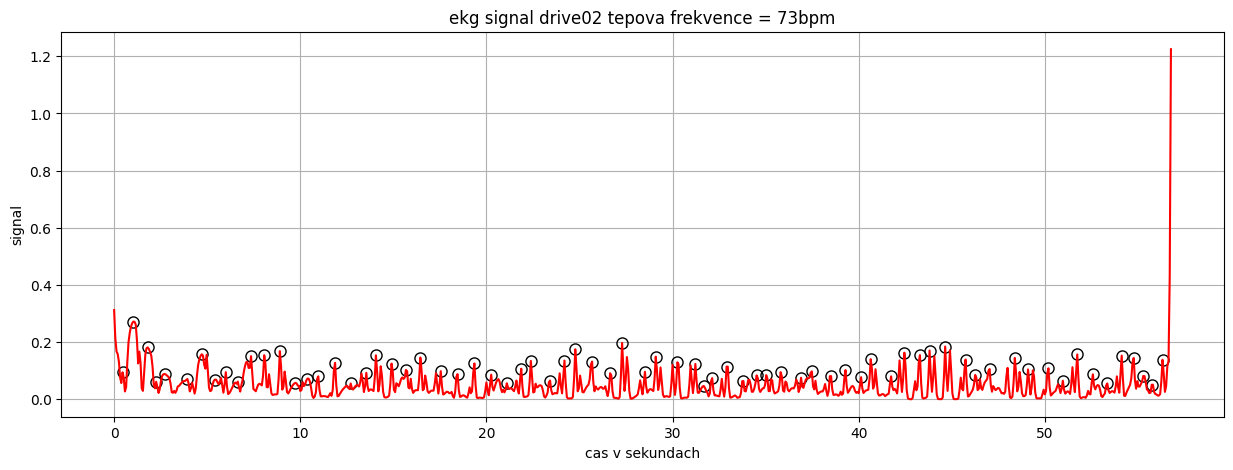

31


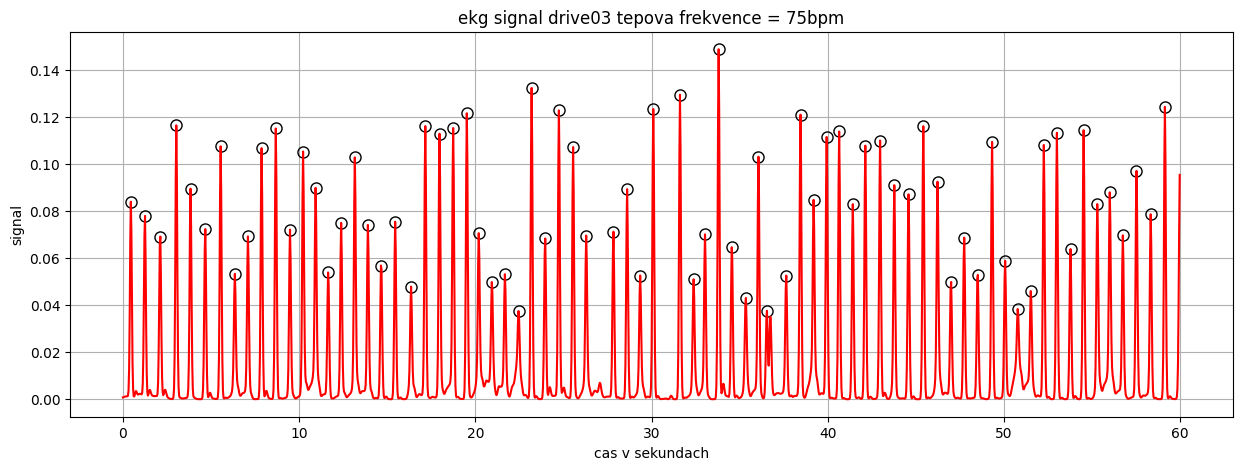

15.5


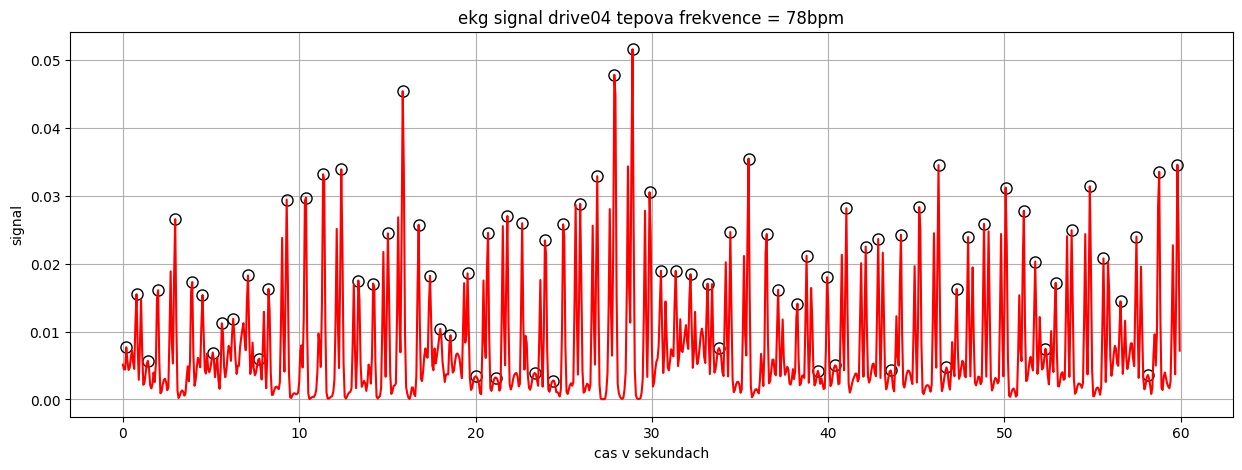

15.5


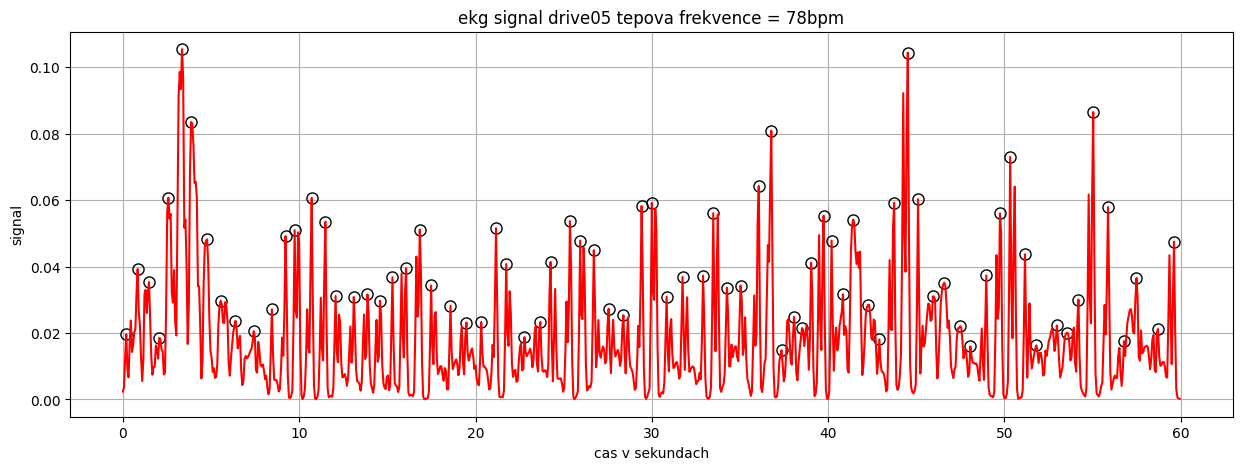

15.5


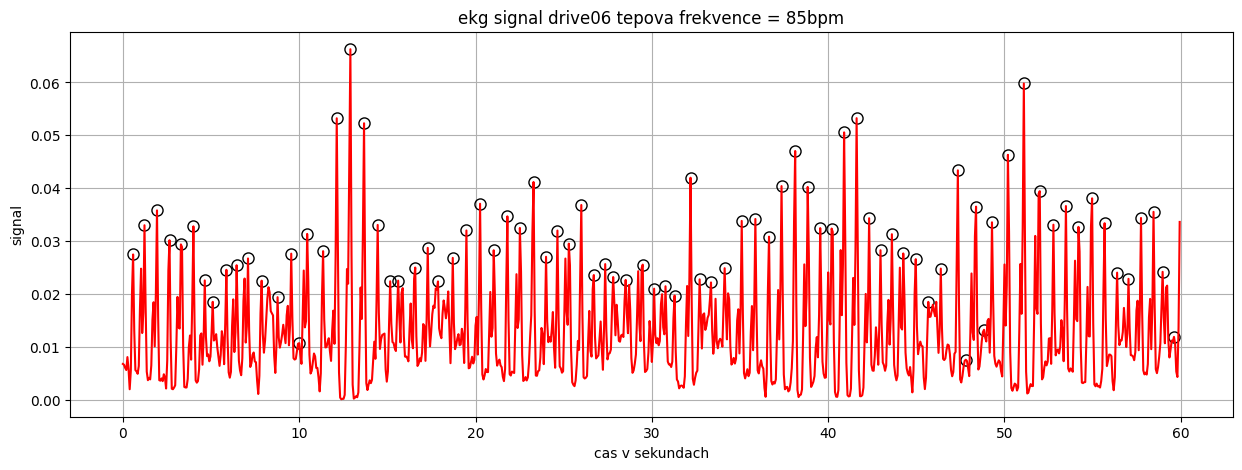

15.5


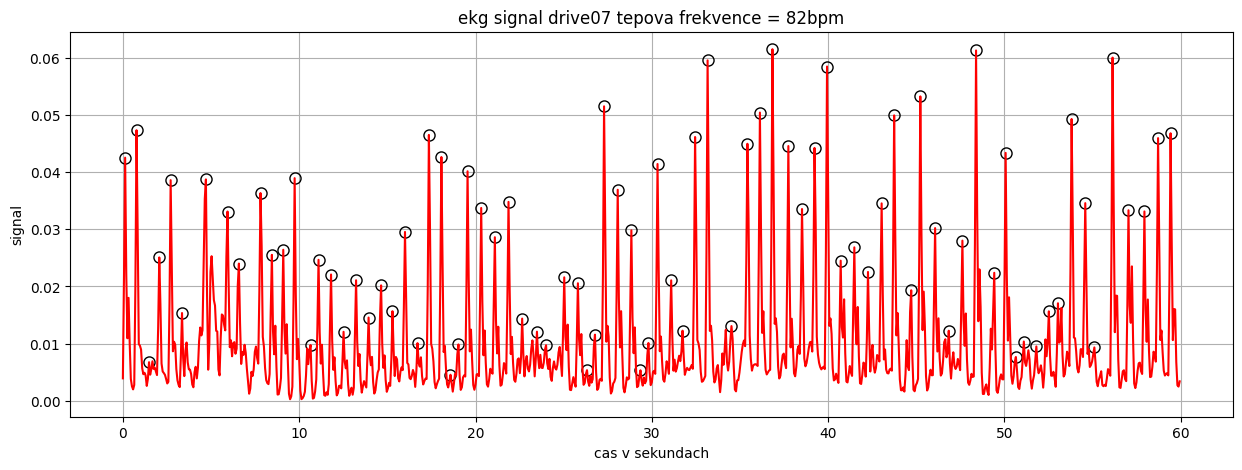

15.5


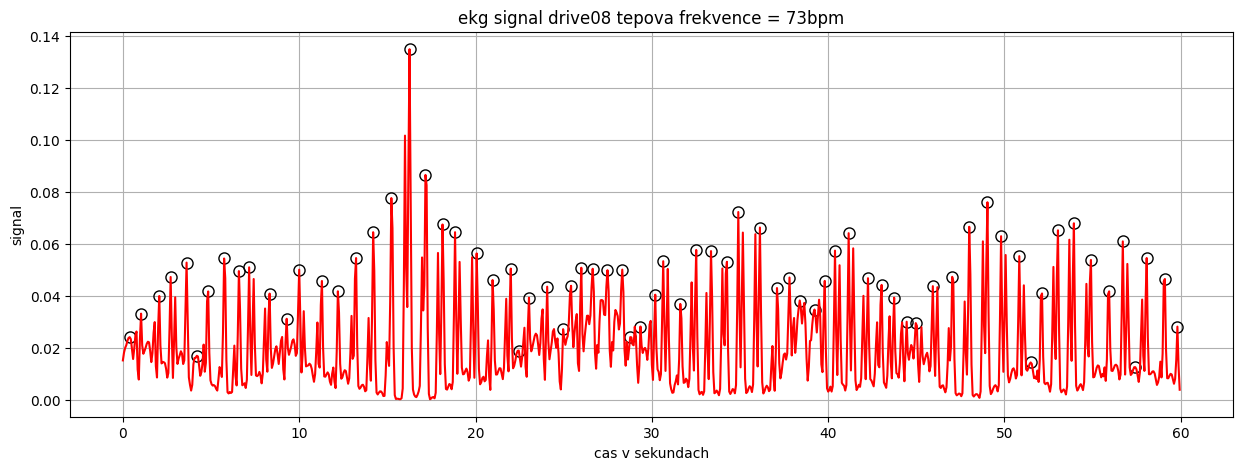

15.5


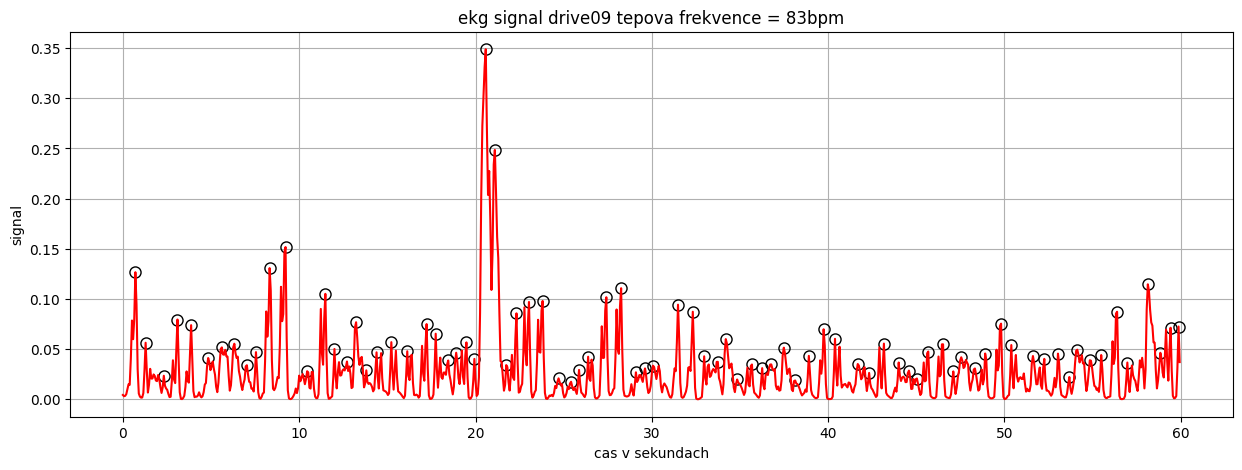

15.5


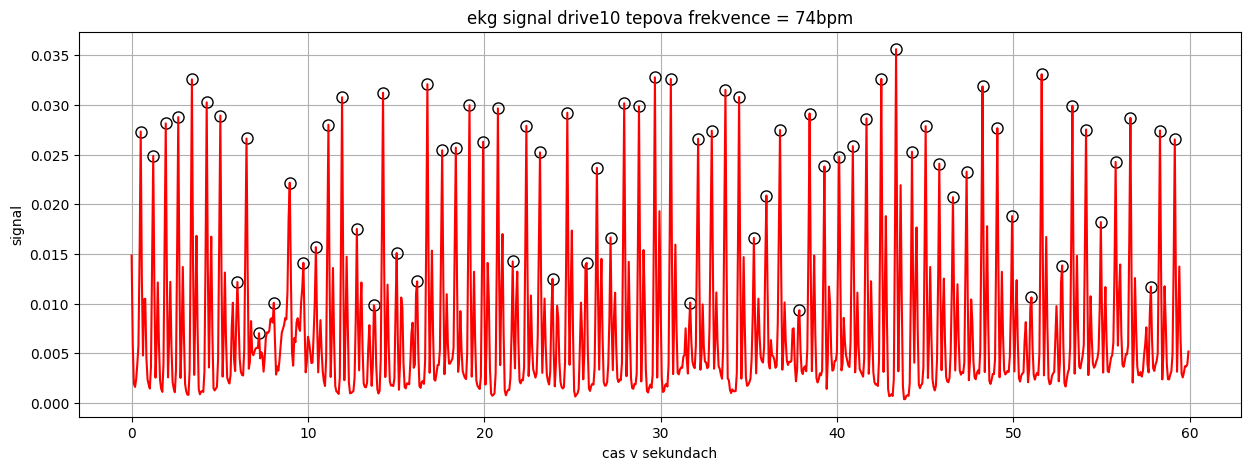

15.5


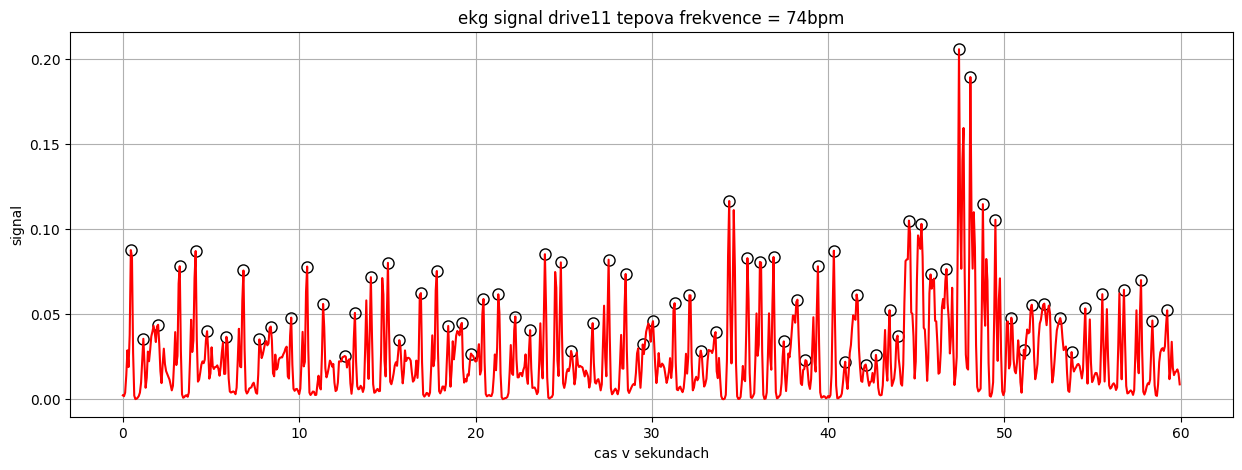

15.5


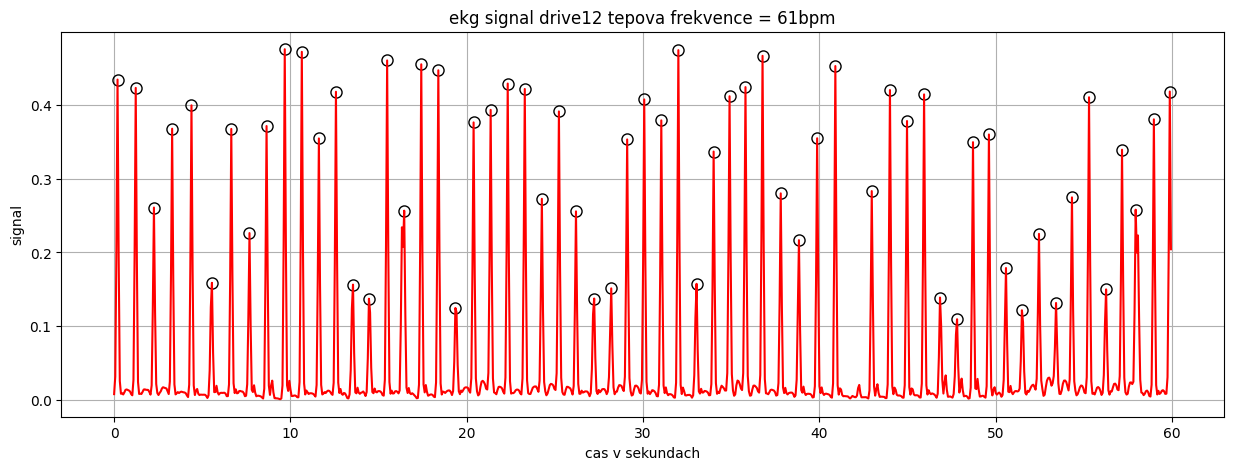

15.5


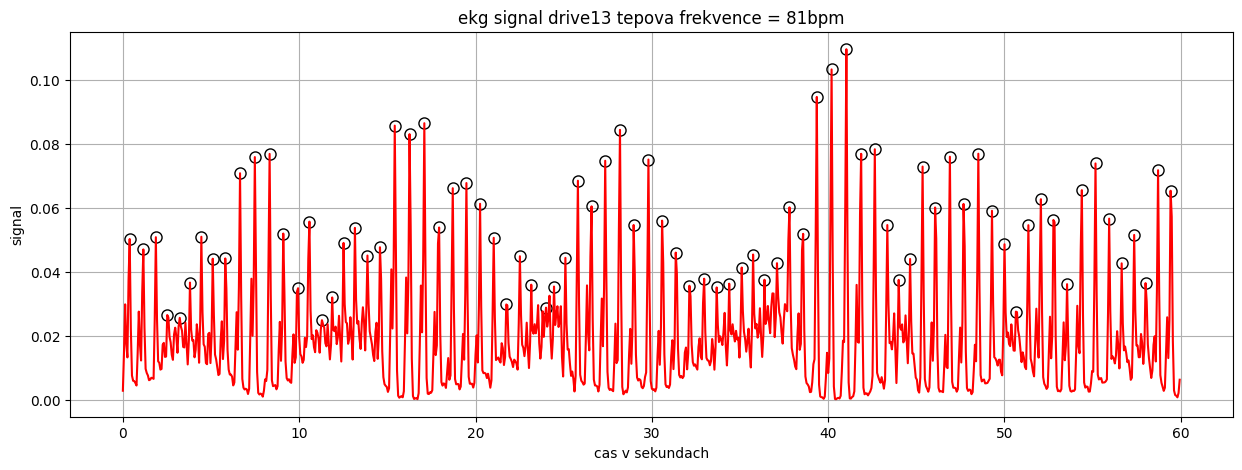

15.5


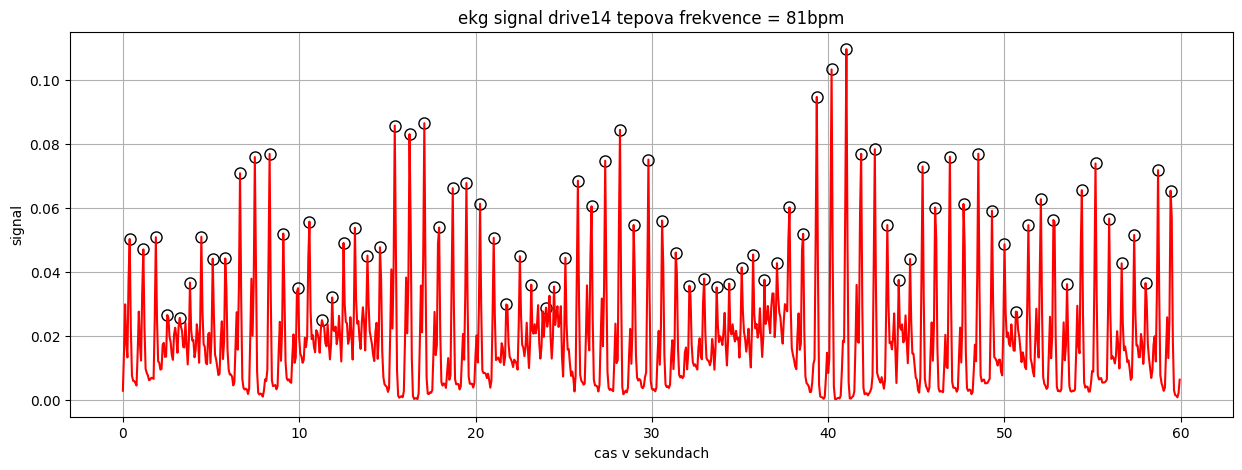

15.5


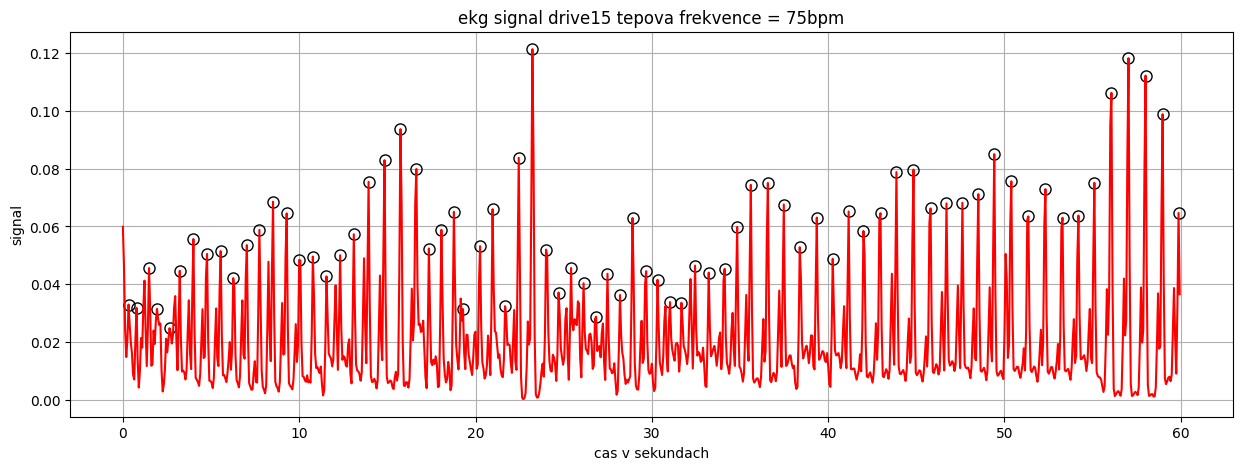

15.5


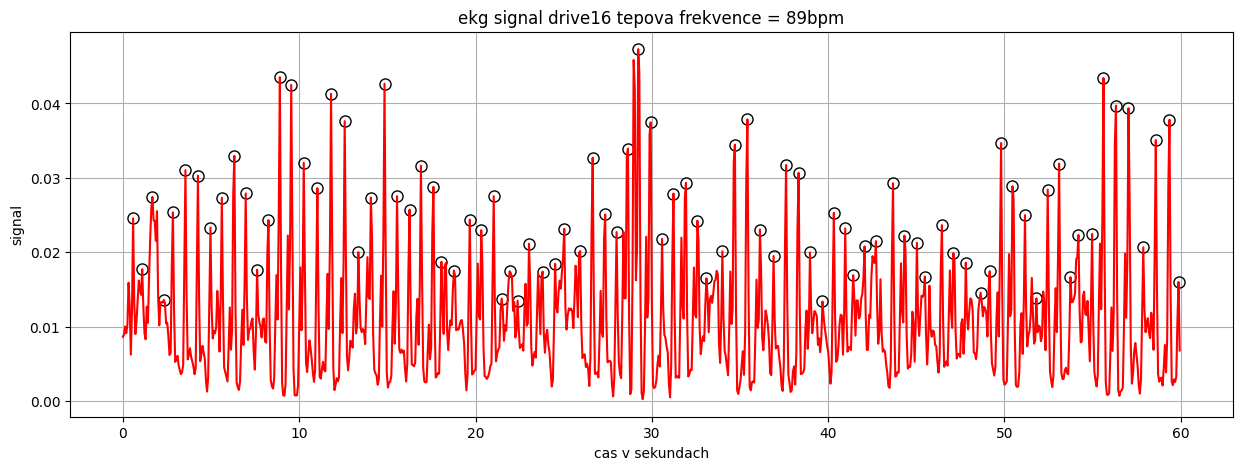

15


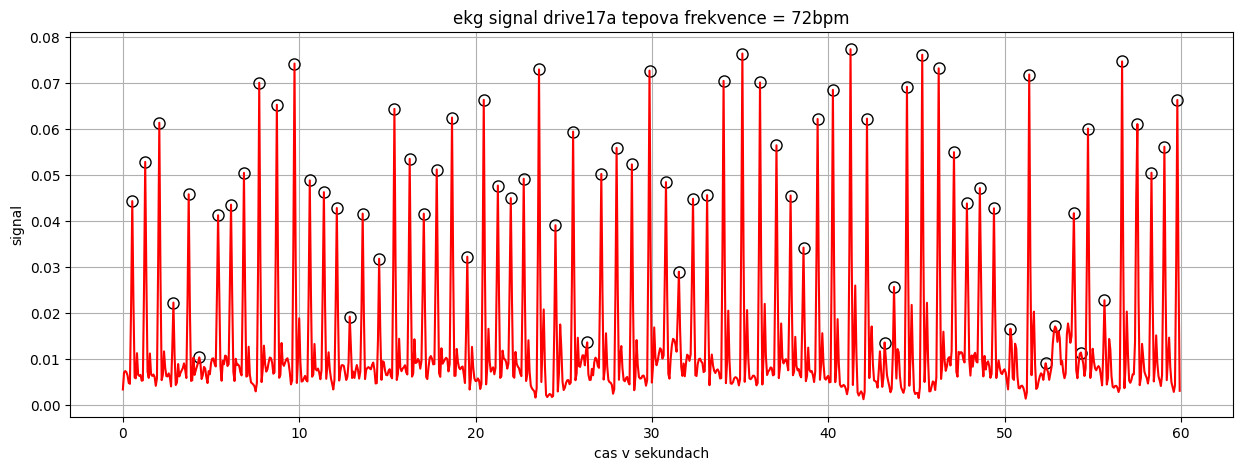

15.5


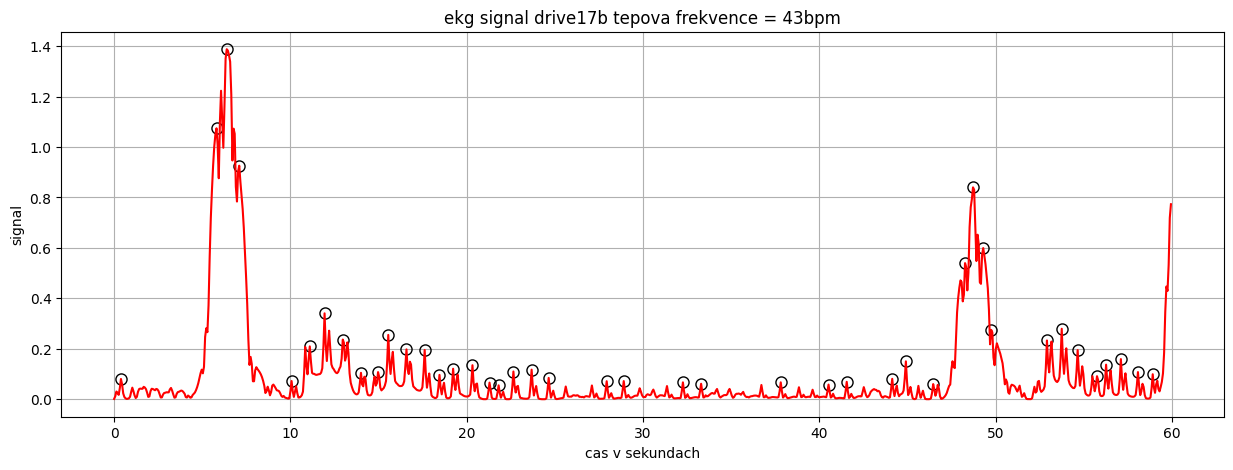

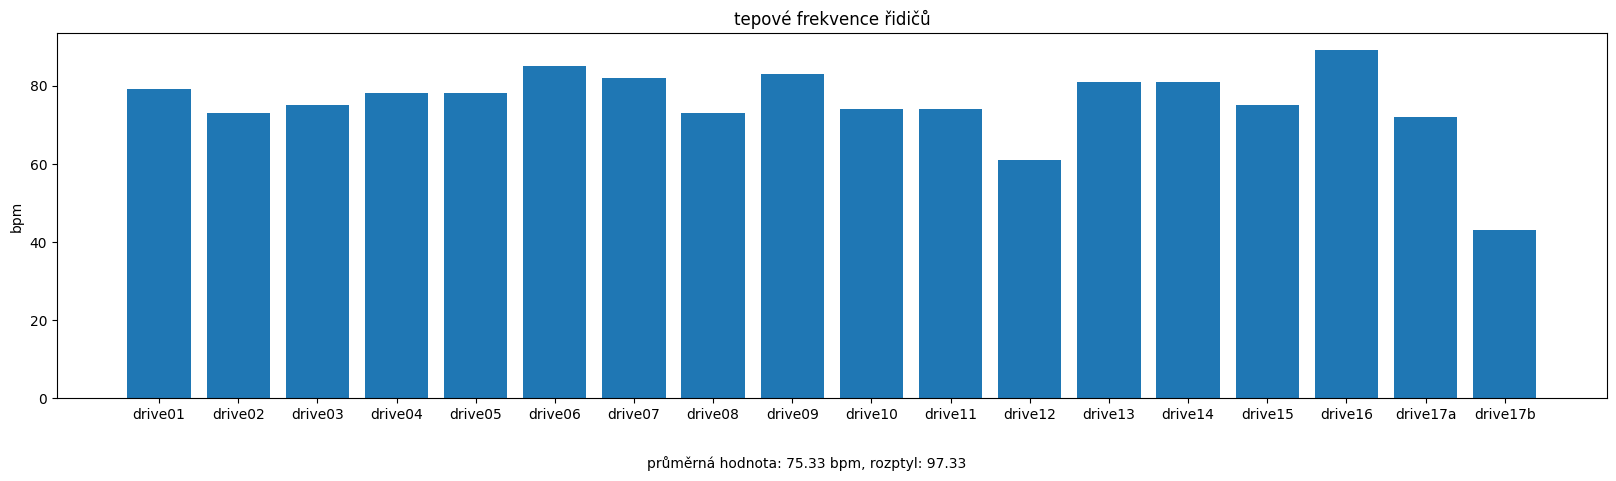

In [26]:
results_drivers = []

for record in ekg_records:
  fs = record.fs
  print(fs)
  usek = int(fs * 60)
  ekg_signal = (record.p_signal[:, 0][: usek])**2

  results_drivers.append(find_bpm(ekg_signal))

prumer = round(np.mean(results_drivers), 2)
rozptyl = round(np.var(results_drivers), 2)

plt.figure(figsize=(20, 5))
plt.bar(record_names, results_drivers)
plt.title("tepové frekvence řidičů")
plt.ylabel("bpm")
plt.figtext(0.5, 0.01, f"průměrná hodnota: {prumer} bpm, rozptyl: {rozptyl}", ha="center", fontsize=10)
plt.subplots_adjust(bottom=0.15)


In [7]:
#testovaci db
nsrdb_names = get_record_list("nsrdb")

nsrdb_records = []
nsrdb_peaks = []

limit = 60 * 128

for name in nsrdb_names:
  rec = rdrecord(name, pn_dir="nsrdb", sampto=limit);
  annotation = rdann(name, "atr", pn_dir="nsrdb", sampto=limit)
  r_peak_indices = annotation.sample

  nsrdb_records.append(rec)
  nsrdb_peaks.append(len(r_peak_indices))

print(nsrdb_peaks)

[96, 64, 94, 95, 99, 79, 155, 71, 125, 70, 84, 112, 90, 108, 107, 128, 105, 111]


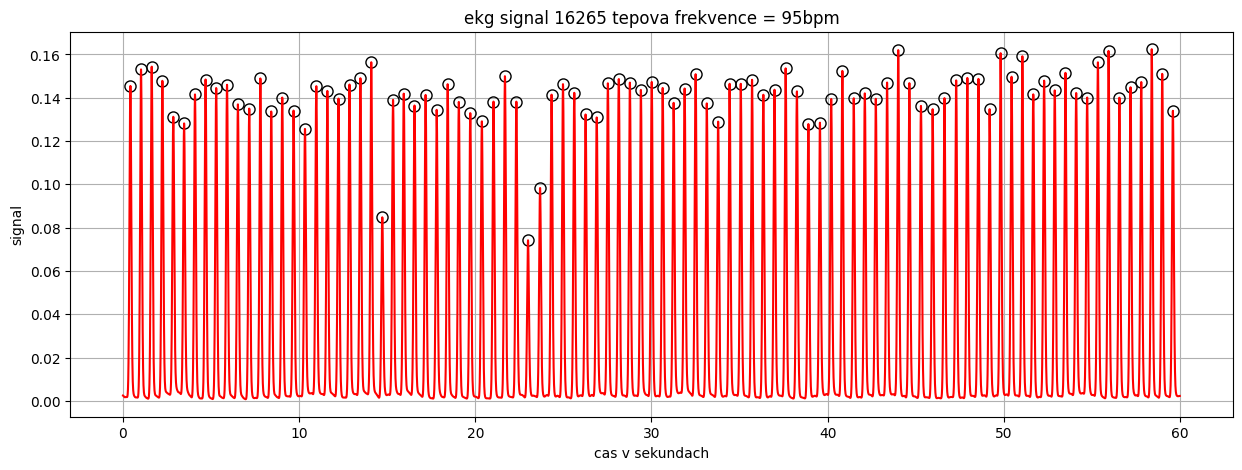

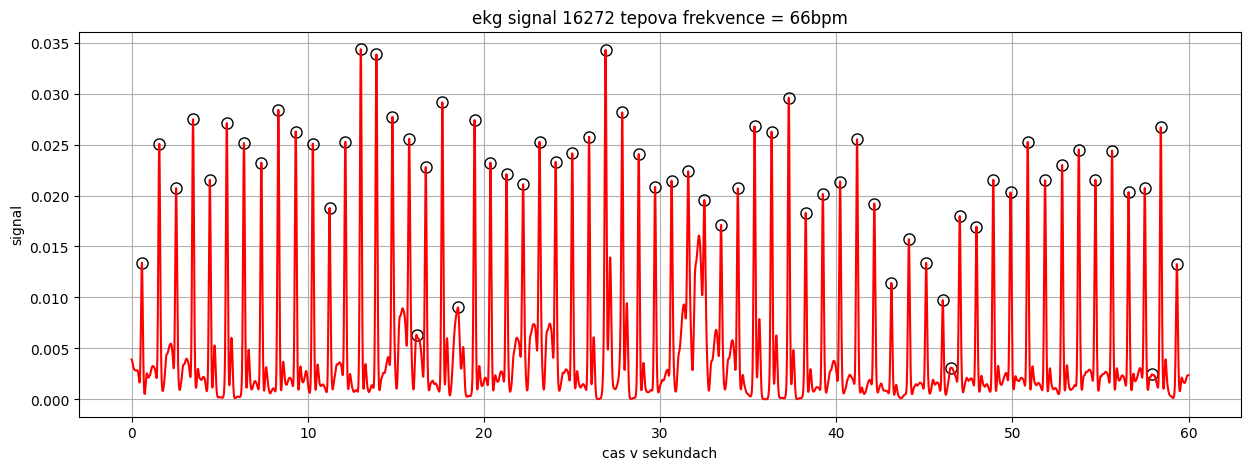

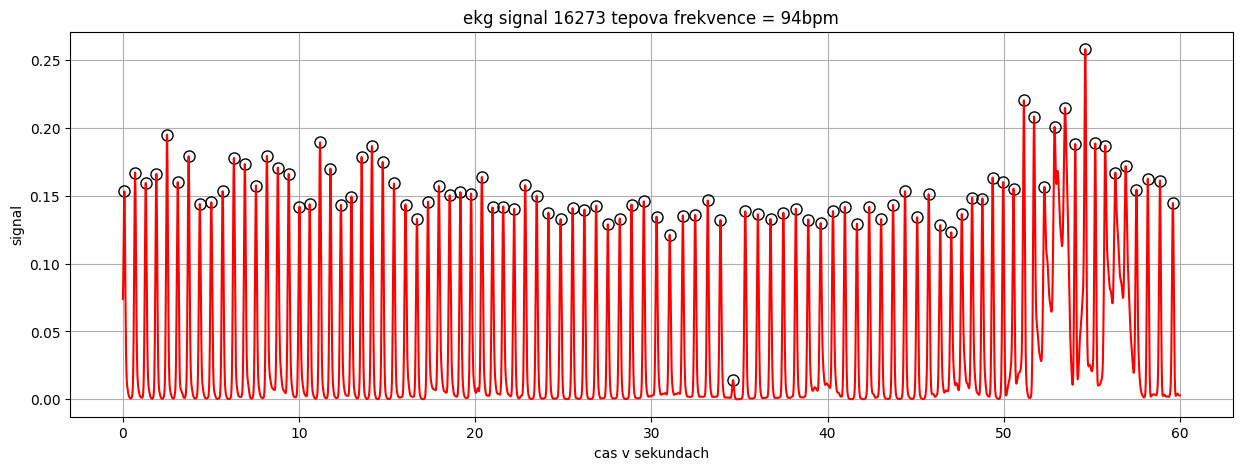

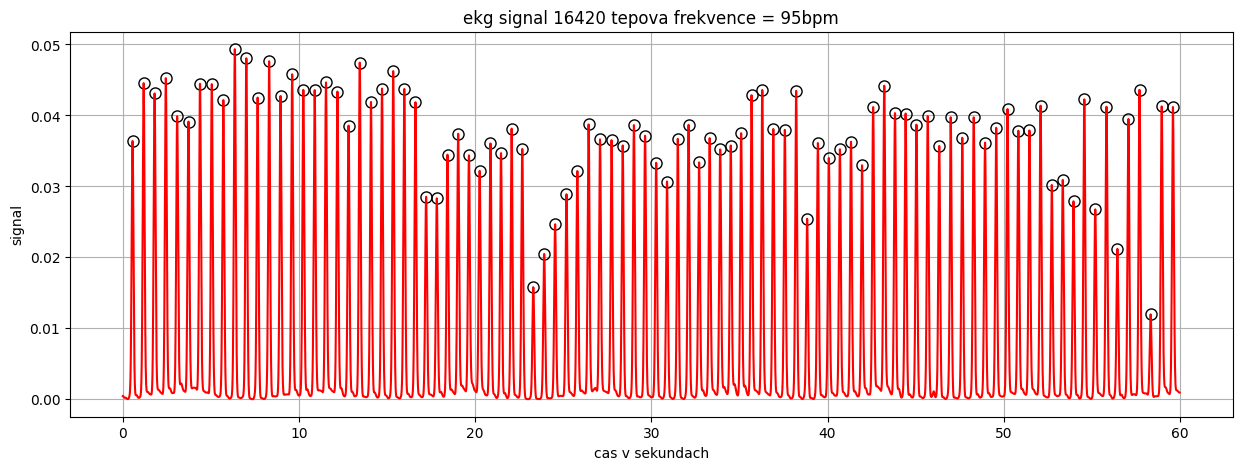

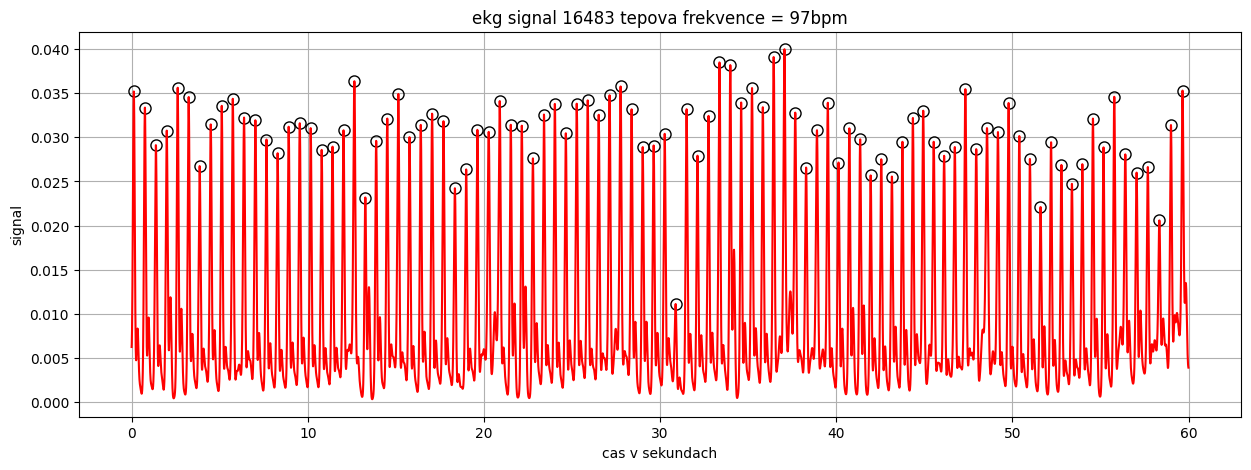

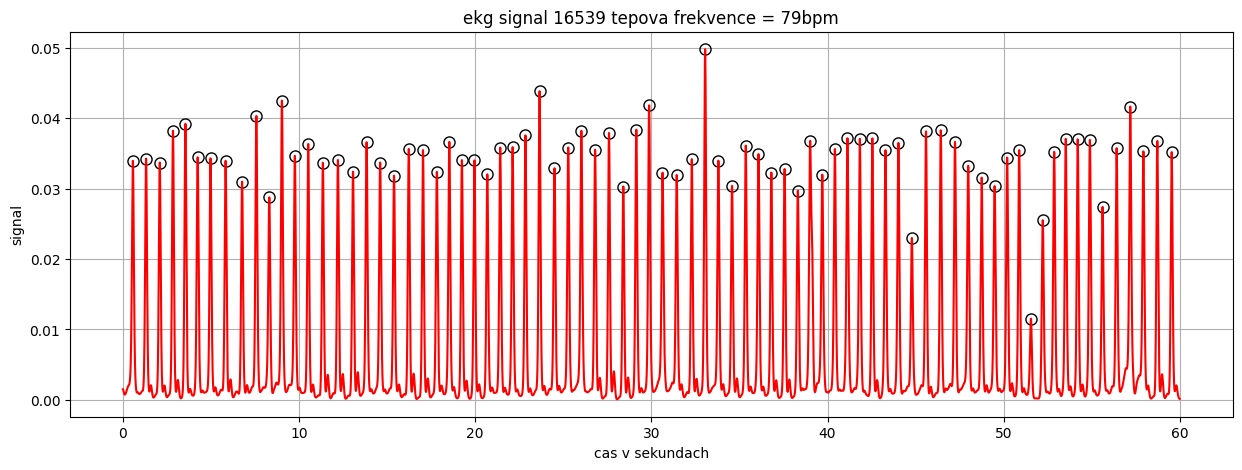

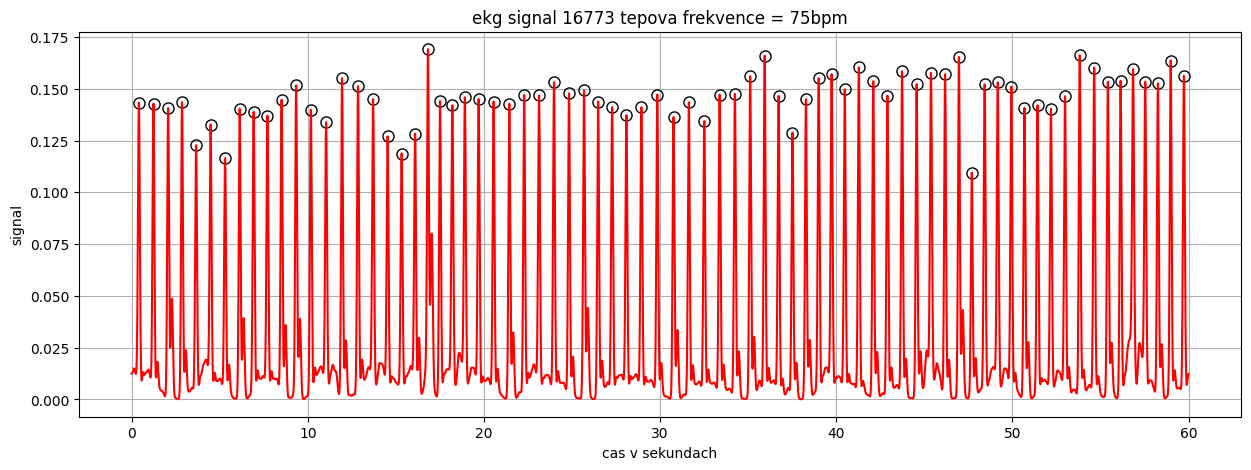

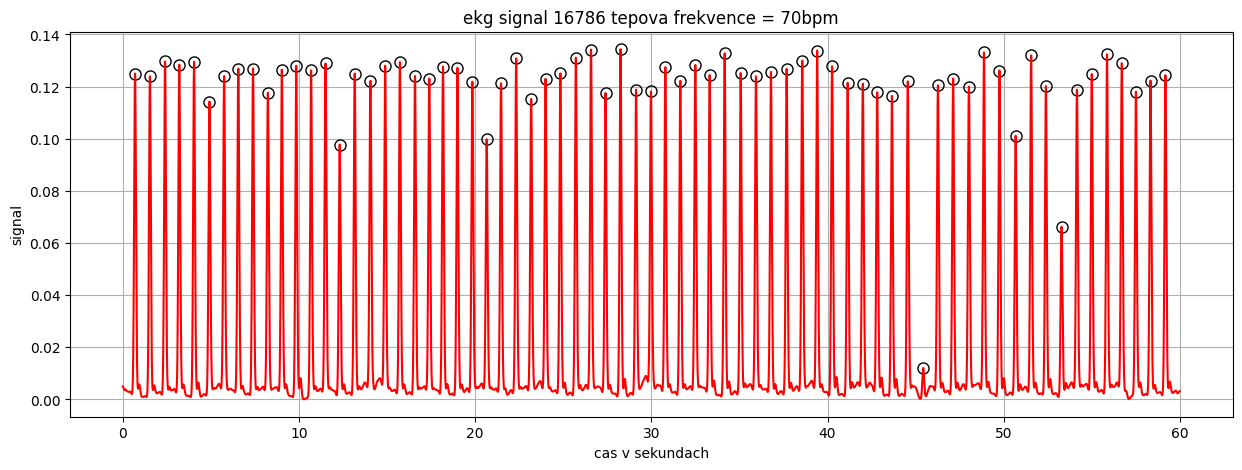

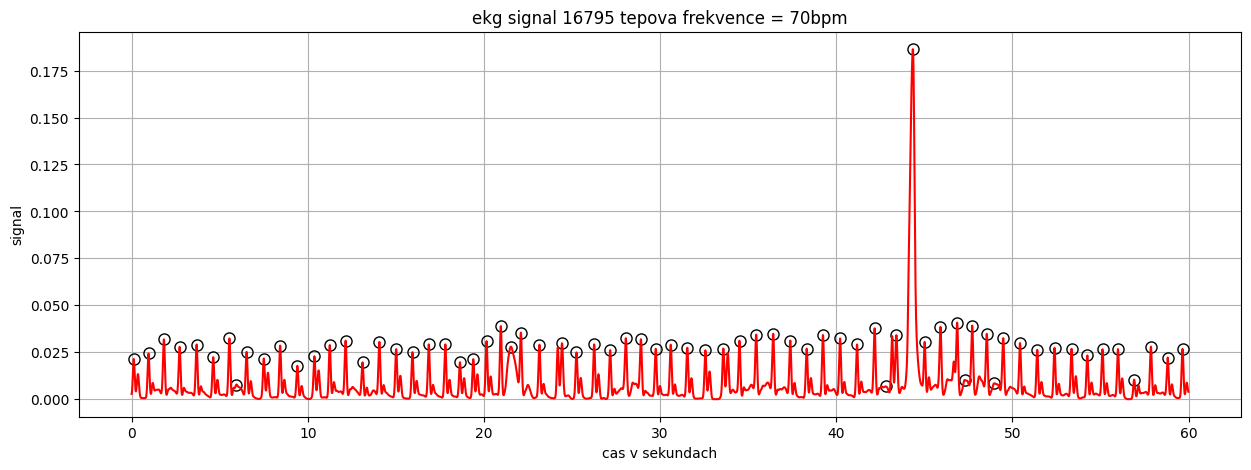

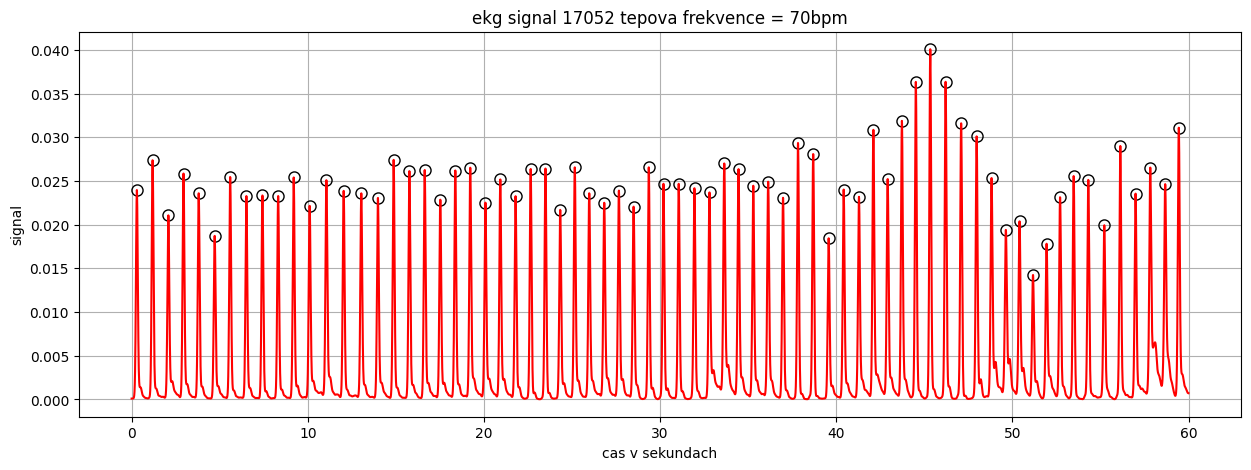

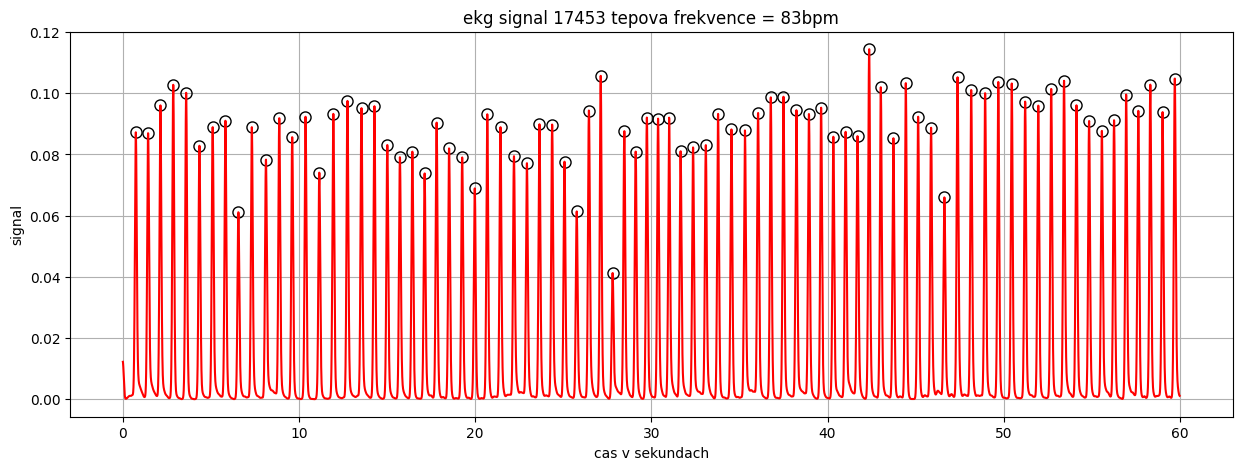

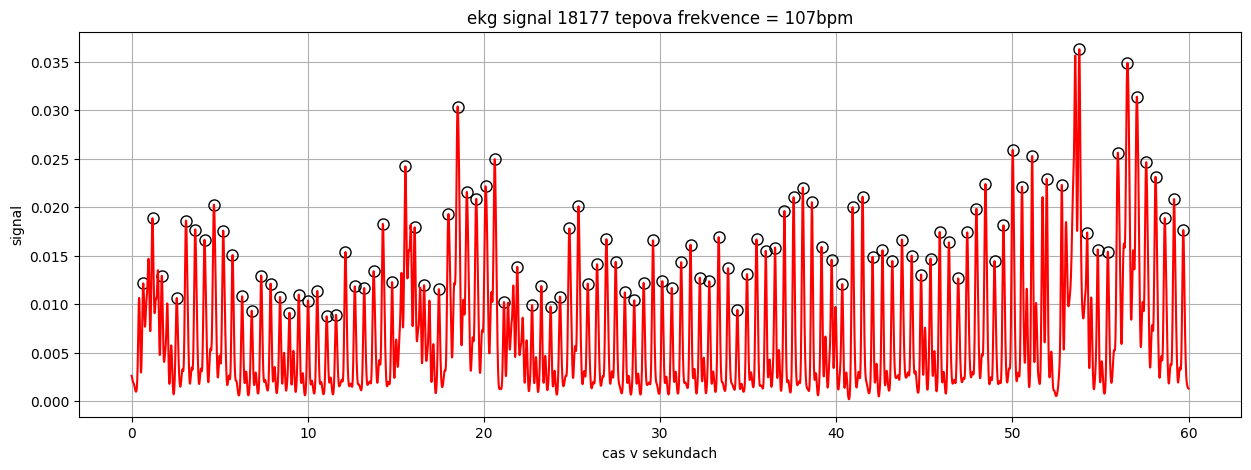

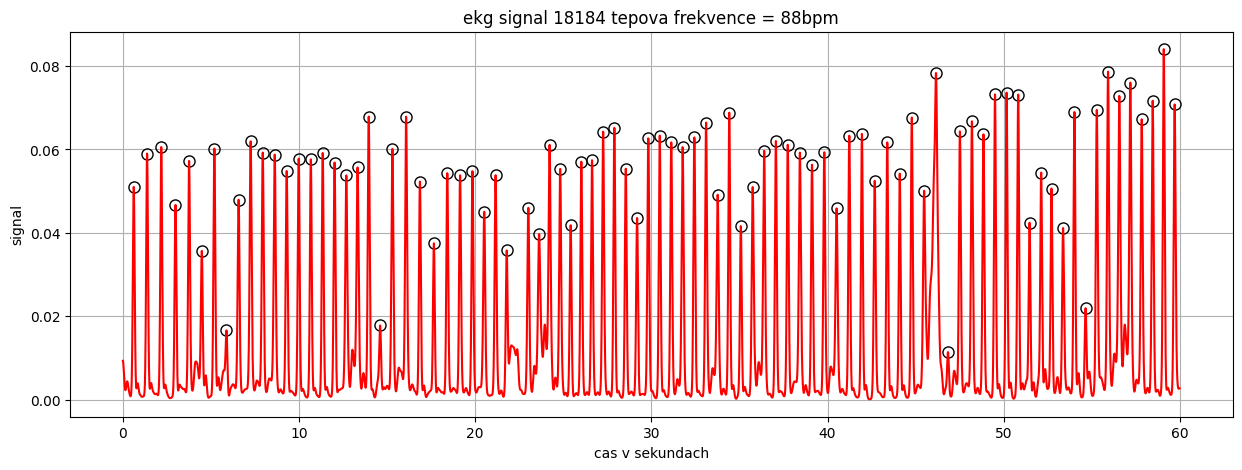

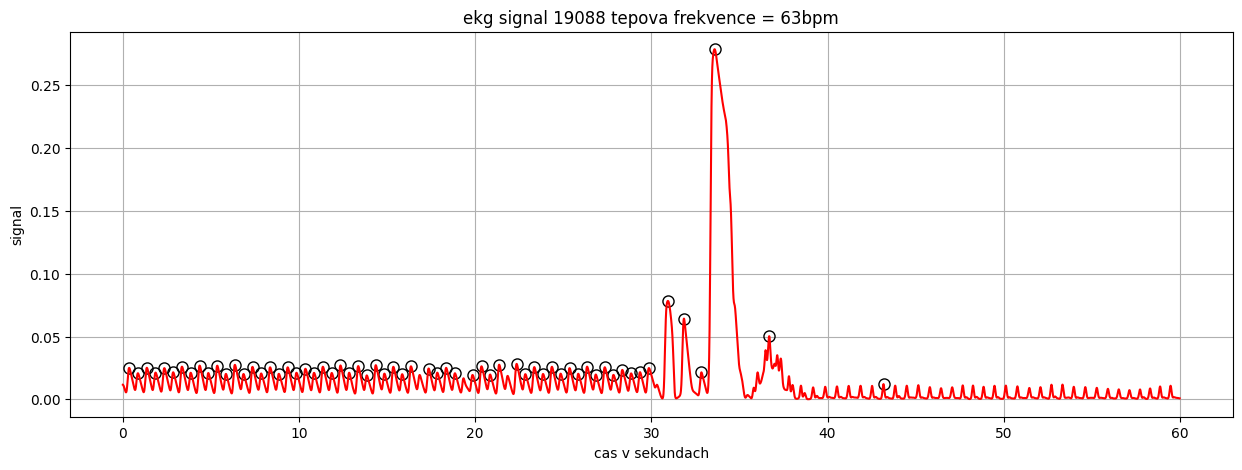

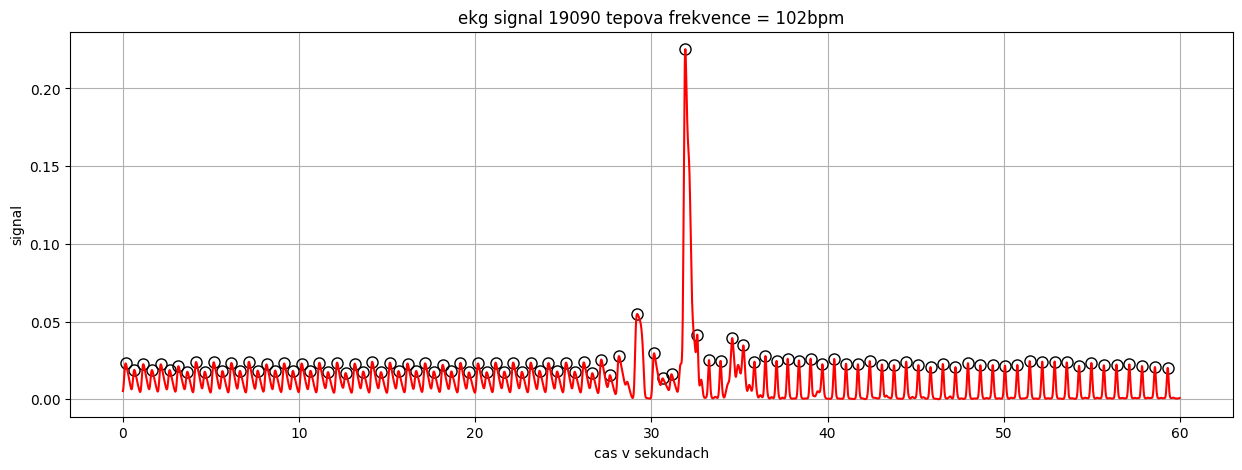

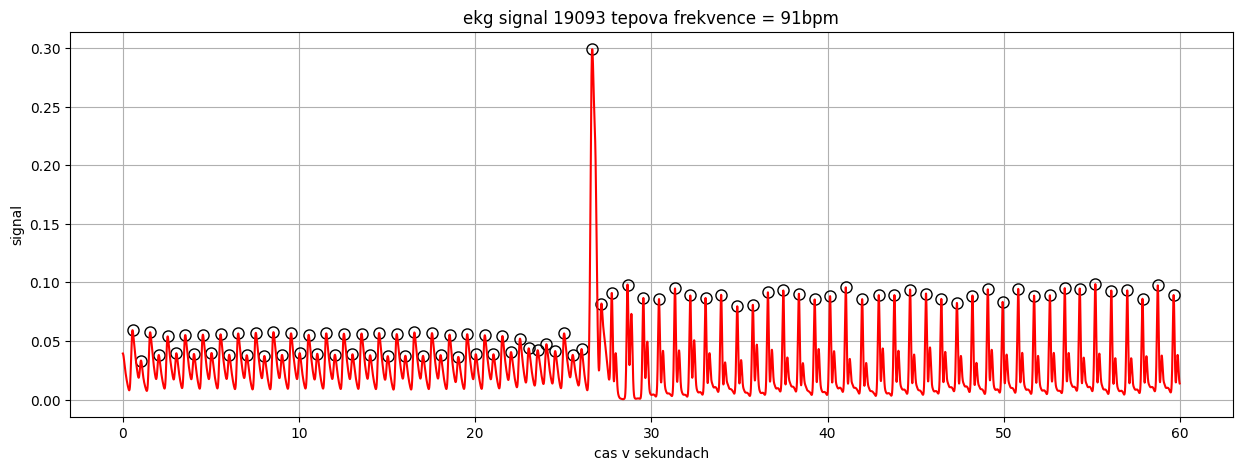

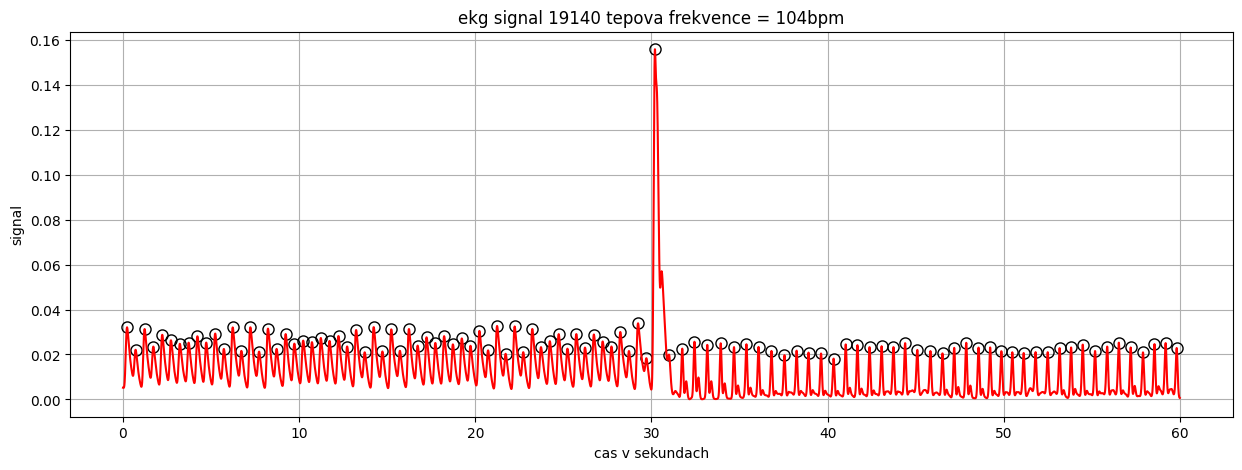

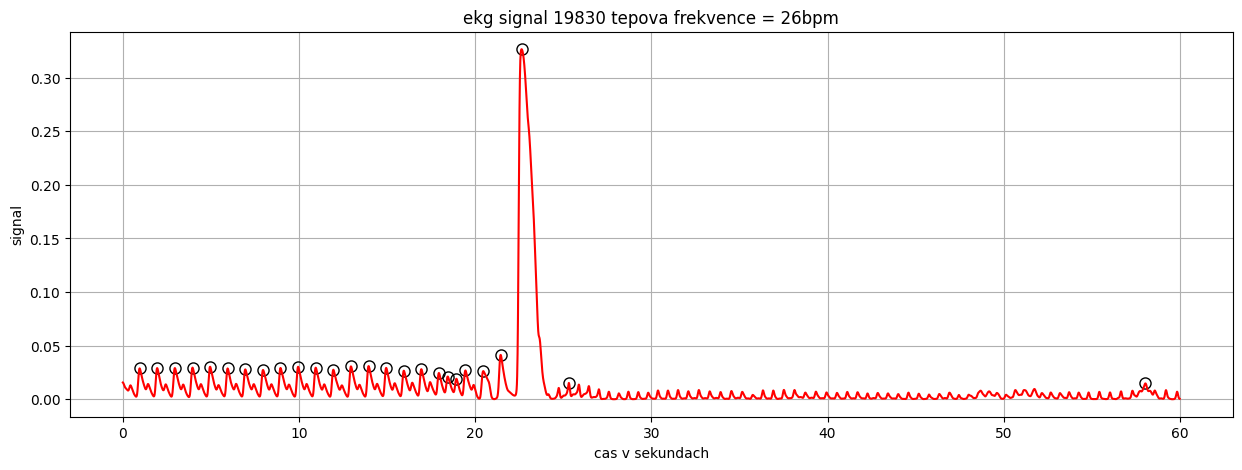

,DB hodnota,Moje hodnota,Shoda
16265,96,95,99
16272,64,66,97
16273,94,94,100
16420,95,95,100
16483,99,97,98
16539,79,79,100
16773,155,75,48
16786,71,70,99
16795,125,70,56
17052,70,70,100


In [8]:
results = []

for record in nsrdb_records:
  ekg_signal = ((record.p_signal[:, 0])**2)/10

  results.append(find_bpm(ekg_signal))

shody = [];

for i in range(len(results)):
  if (results[i] < nsrdb_peaks[i]):
    shody.append(round(results[i]/nsrdb_peaks[i] * 100))
  else:
    shody.append(round(nsrdb_peaks[i]/results[i] * 100))

pd.DataFrame({
    "DB hodnota": nsrdb_peaks,
    "Moje hodnota": results,
    "Shoda": shody
}, index=nsrdb_names)



### **2. Výpočet korelace měřených signálů**

In [29]:
charisdb_names = get_record_list("charisdb")

charisdb_records = []

limit = 60 * 60 * 50 # 1 hodina

for name in charisdb_names:
  rec = rdrecord(name, pn_dir="charisdb", sampto=limit);
  charisdb_records.append(rec)


name:charis10 fs:50


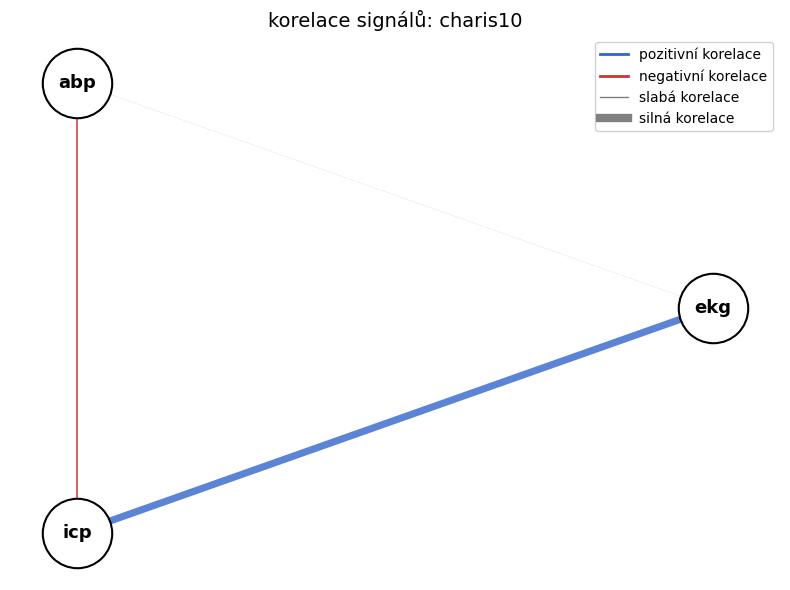

name:charis11 fs:50


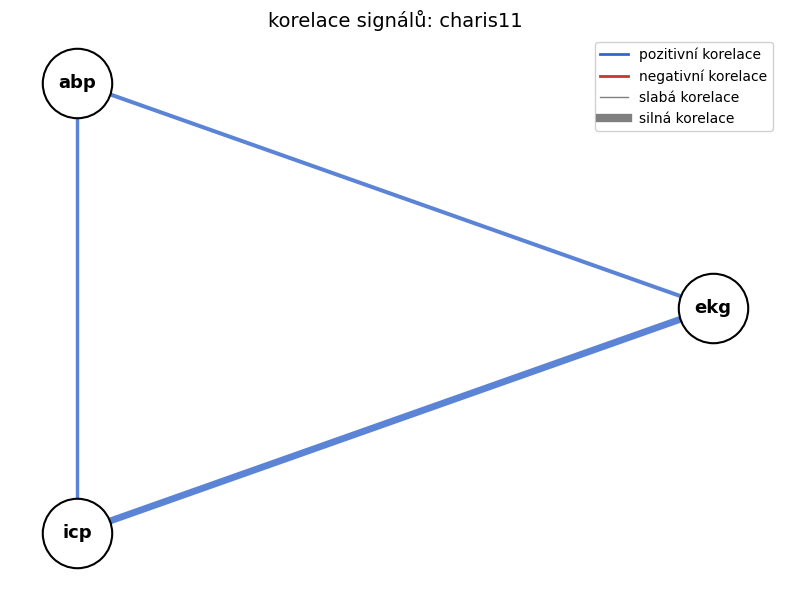

name:charis12 fs:50


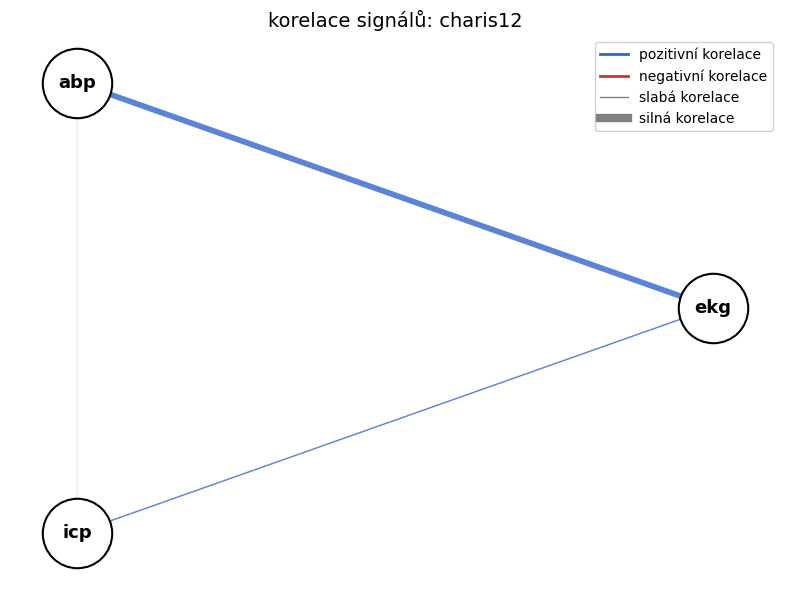

name:charis13 fs:50


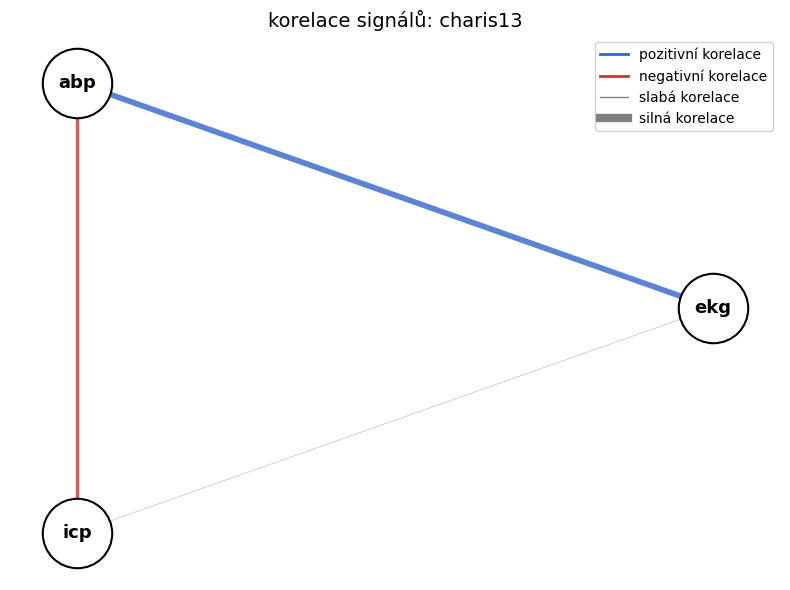

name:charis1 fs:50


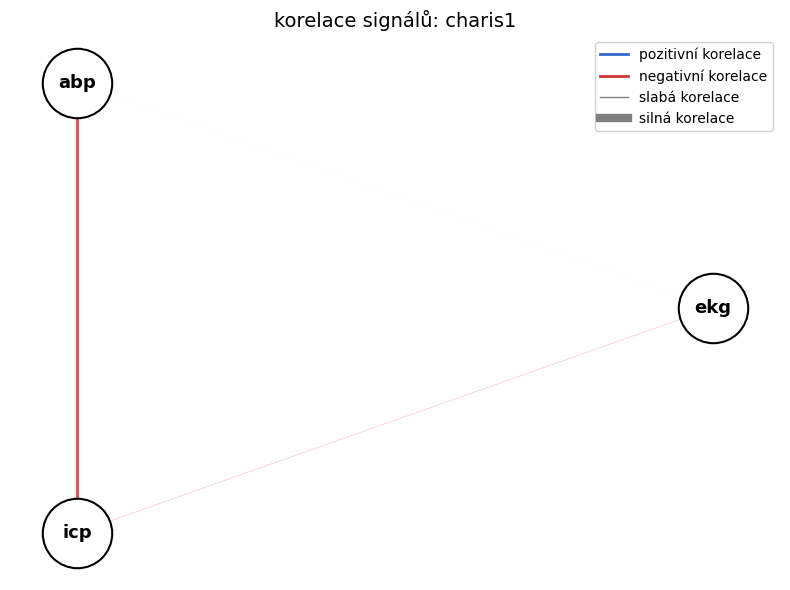

name:charis2 fs:50


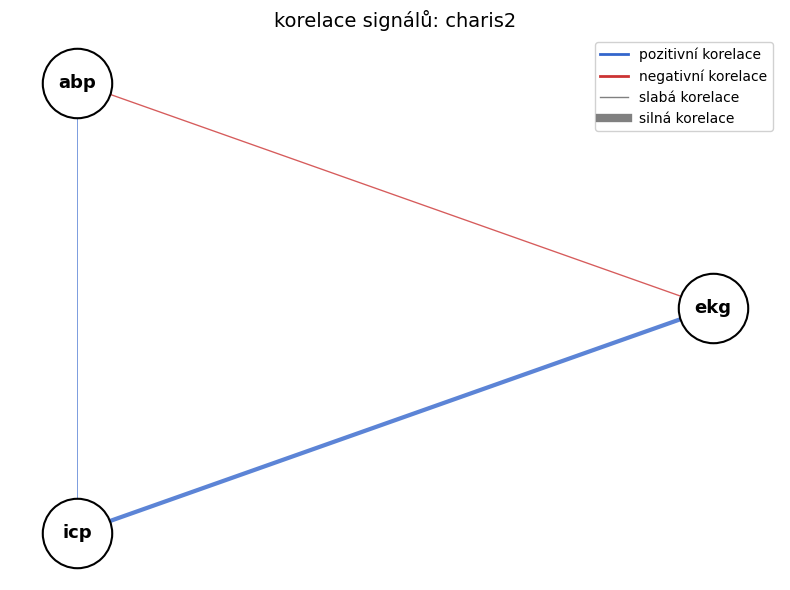

name:charis3 fs:50


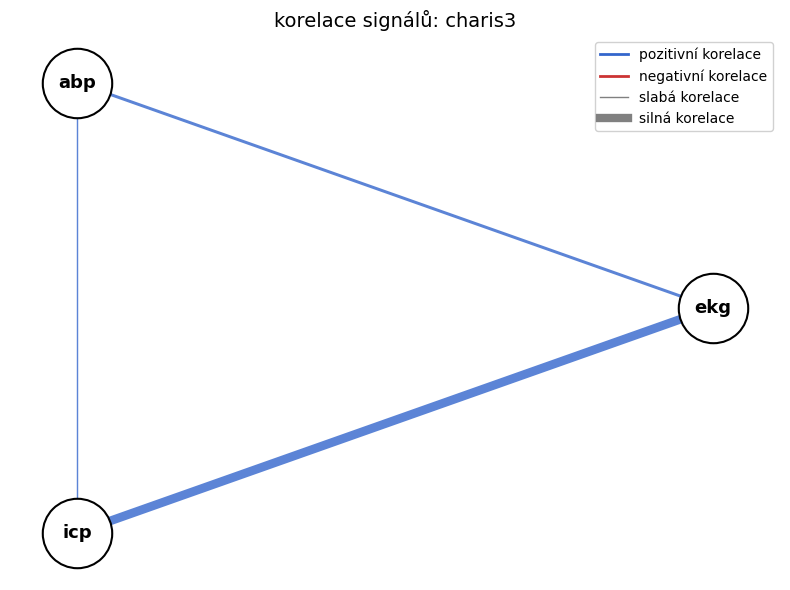

name:charis4 fs:50


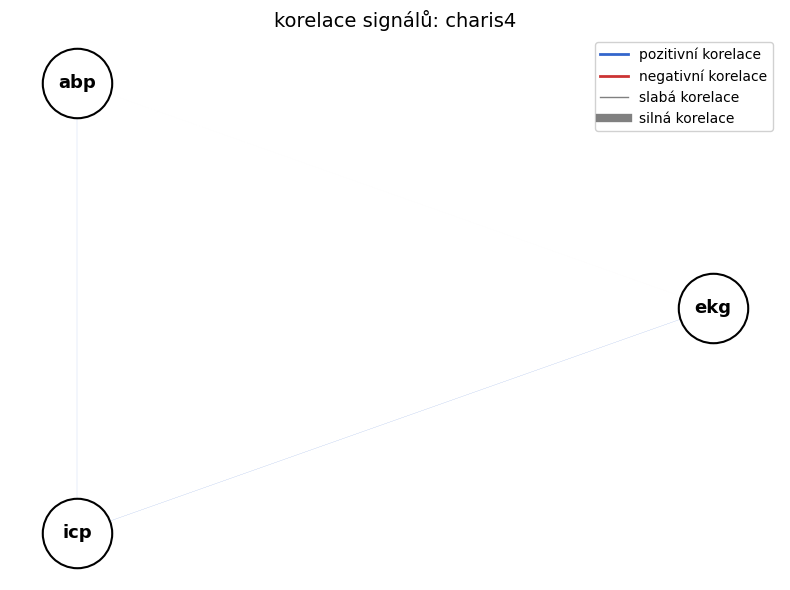

name:charis5 fs:50


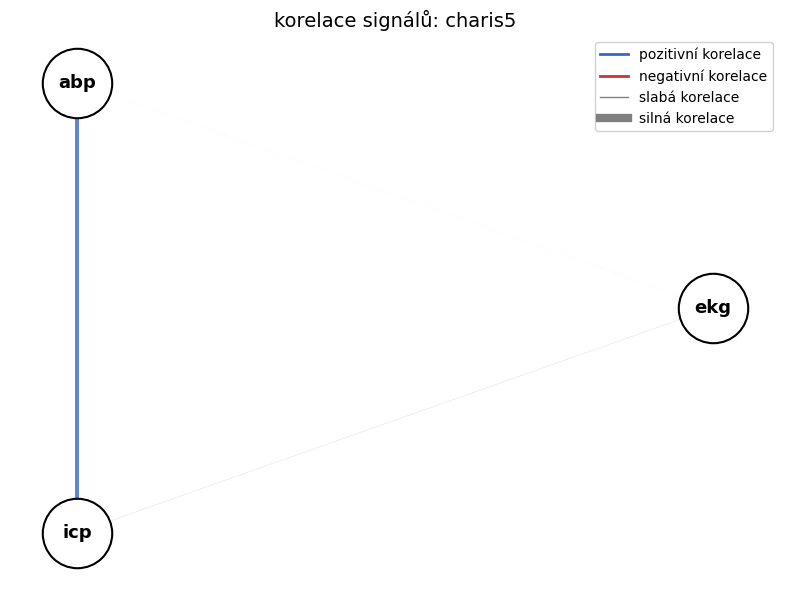

name:charis6 fs:50


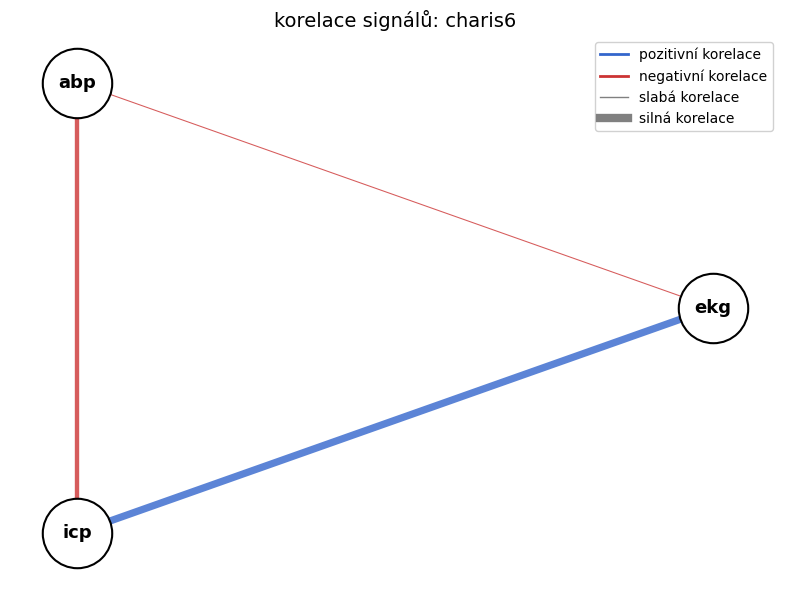

name:charis7 fs:50


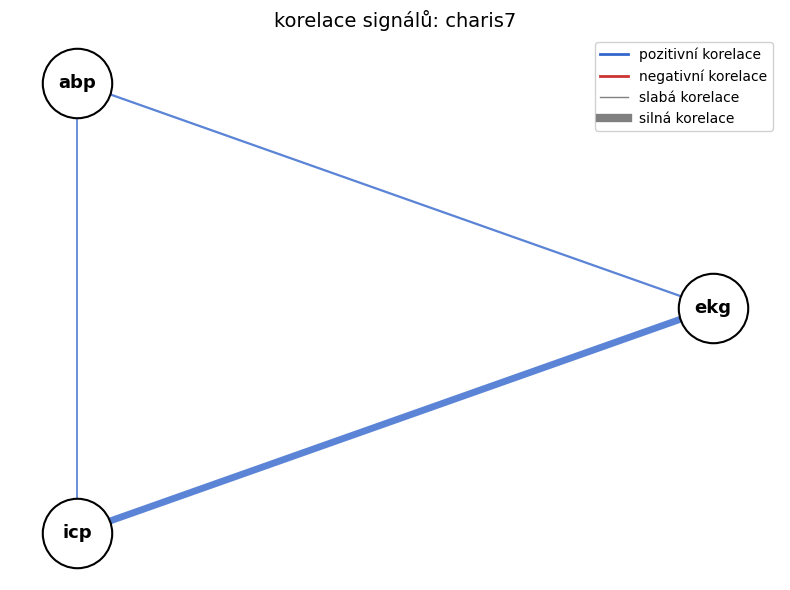

name:charis8 fs:50


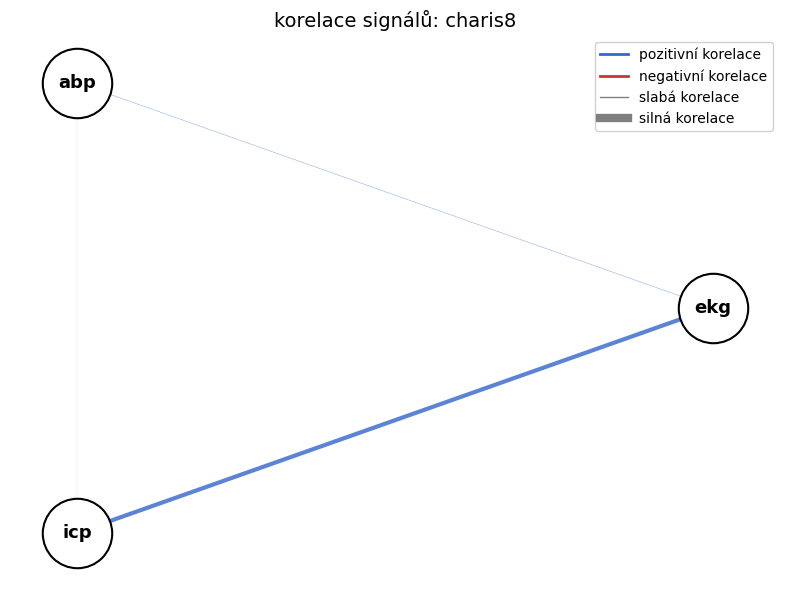

name:charis9 fs:50


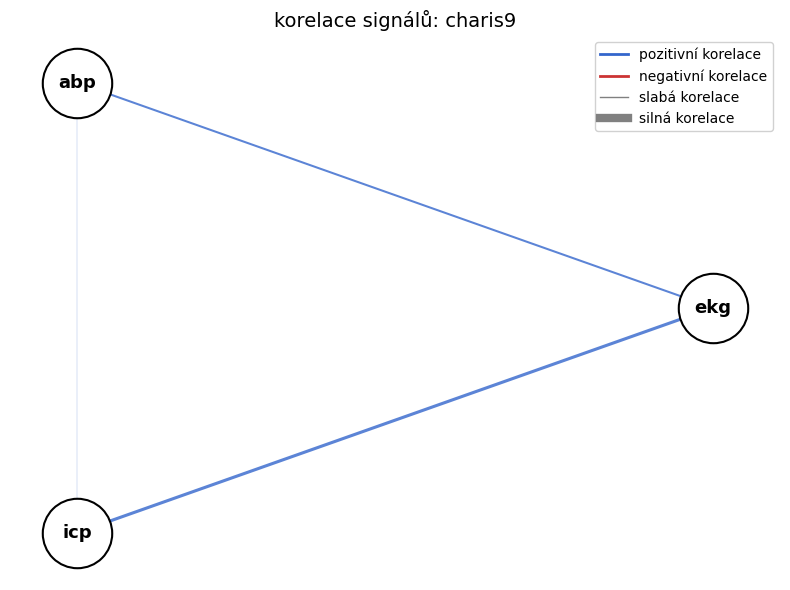

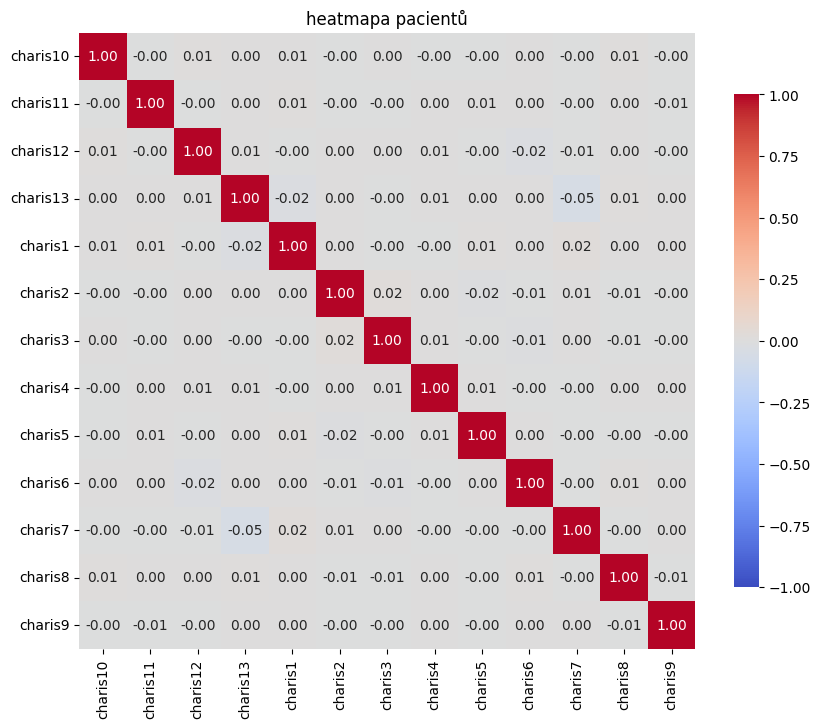

In [45]:
def normalizace_signalu(signal):
  bez_nan = signal[~np.isnan(signal)]

  q1 = np.percentile(bez_nan, 25)
  q3 = np.percentile(bez_nan, 75)
  IQR = q3 - q1

  horni_hranice = q3 + 1.5 * IQR
  dolni_hranice = q1 - 1.5 * IQR

  indices = np.where((signal > horni_hranice) | (signal < dolni_hranice))[0]

  signal[indices] = np.nan

  series = pd.Series(signal)

  new_signal = series.interpolate(method="linear").ffill().bfill()

  n_q3, n_q1 = np.percentile(new_signal, [75, 25])
  n_IQR = n_q3 - n_q1;
  median = np.median(new_signal)

  new_signal = (new_signal - median) / n_IQR

  return new_signal;

def peak(fs, signal):
  okno = fs * 10
  vzdalenost = int(fs * 0.5)
  peaks, _ = find_peaks(signal[:okno], distance=vzdalenost, prominence=0.5)
  return peaks[0] if len(peaks) > 0 else 0;

def posun_na_peaks(ekg, abp, icp, fs, time):
  peak_ekg = peak(fs, ekg)
  peak_abp = peak(fs, abp)
  peak_icp = peak(fs, icp)

  ekg_posun = ekg[peak_ekg:]
  abp_posun = abp[peak_abp:]
  icp_posun = icp[peak_icp:]

  nejkratsi_signal = min(len(ekg_posun), len(abp_posun), len(icp_posun))

  return ekg_posun[: nejkratsi_signal], abp_posun[: nejkratsi_signal], icp_posun[: nejkratsi_signal], time[: nejkratsi_signal]


def korelace_signalu(name, ekg, abp, icp, fs):
  print(f"name:{name} fs:{fs}");

  time = np.arange(ekg.shape[0]) / fs

  fix_ekg = normalizace_signalu(ekg)
  fix_abp = normalizace_signalu(abp)
  fix_icp = normalizace_signalu(icp)

  posun_ekg, posun_abp, posun_icp, posun_time = posun_na_peaks(fix_ekg, fix_abp, fix_icp, fs, time)

  df_signalu = pd.DataFrame({"ekg": ekg, "abp": abp, "icp": icp})
  kor_matice = df_signalu.corr()

  plt.figure(figsize=(8, 6))

  G = nx.Graph()
  sloupce = kor_matice.columns
  G.add_nodes_from(sloupce)
  hrany, vaha, barva = [], [], []

  for i in range(len(sloupce)):
    for j in range(i + 1, len(sloupce)):
      sig1 = sloupce[i]
      sig2 = sloupce[j]
      corr = kor_matice.loc[sig1, sig2]

      hrany.append((sig1, sig2))
      vaha.append(abs(corr) * 8)
      barva.append("#3366cc" if corr > 0 else "#cc3333")

  pos = nx.circular_layout(G)

  nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="white", edgecolors="black", linewidths=1.5)
  nx.draw_networkx_labels(G, pos, font_size=13, font_weight="bold")
  nx.draw_networkx_edges(G, pos, edgelist=hrany, width=vaha, edge_color=barva, alpha=0.8)
  plt.title(f"korelace signálů: {name}", fontsize=14)
  plt.axis("off")
  plt.tight_layout()

  legenda = [
    Line2D([0], [0], color="#3366cc", lw=2, label="pozitivní korelace"),
    Line2D([0], [0], color="#cc3333", lw=2, label="negativní korelace"),
    Line2D([0], [0], color="gray", lw=1, label="slabá korelace"),
    Line2D([0], [0], color="gray", lw=6, label="silná korelace"),
  ]

  plt.legend(handles=legenda, loc="upper right", frameon=True, fancybox=True, framealpha=0.9)
  plt.show()

  return posun_abp, kor_matice

abps_ridicu = {};
kor_matice = [];

for r in charisdb_records:
  abp, matice = korelace_signalu(r.record_name, r.p_signal[:, 0], r.p_signal[:, 1], r.p_signal[:, 2], r.fs);

  kor_matice.append(matice)
  abps_ridicu[r.record_name] = abp

df_ridicu = pd.DataFrame(abps_ridicu)
korelace_ridicu = df_ridicu.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(korelace_ridicu, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, fmt=".2f", cbar_kws={"shrink": 0.8})
plt.title("heatmapa pacientů")
plt.show()

In [42]:
korelace_ridicu

,charis10,charis11,charis12,charis13,charis1,charis2,charis3,charis4,charis5,charis6,charis7,charis8,charis9
charis10,1.000000,-0.000871,0.013549,0.003120,0.006812,-0.000565,0.002938,-0.002291,-0.003152,0.000806,-0.003343,0.012249,-0.004204
charis11,-0.000871,1.000000,-0.000148,0.002298,0.008698,-0.004106,-0.000809,0.000343,0.005340,0.001068,-0.004832,0.004948,-0.006489
charis12,0.013549,-0.000148,1.000000,0.007079,-0.003274,0.004513,0.001374,0.005974,-0.000956,-0.017251,-0.005705,0.001191,-0.001152
charis13,0.003120,0.002298,0.007079,1.000000,-0.018482,0.001276,-0.003160,0.007772,0.004993,0.002045,-0.049309,0.009246,0.000246
charis1,0.006812,0.008698,-0.003274,-0.018482,1.000000,0.003702,-0.000584,-0.004730,0.010960,0.000377,0.017156,0.001365,0.002323
charis2,-0.000565,-0.004106,0.004513,0.001276,0.003702,1.000000,0.015882,0.000923,-0.015102,-0.005239,0.005844,-0.005505,-0.003964
charis3,0.002938,-0.000809,0.001374,-0.003160,-0.000584,0.015882,1.000000,0.006018,-0.000736,-0.008348,0.000325,-0.006691,-0.002423
charis4,-0.002291,0.000343,0.005974,0.007772,-0.004730,0.000923,0.006018,1.000000,0.006086,-0.000749,-0.002222,0.001541,0.001981
charis5,-0.003152,0.005340,-0.000956,0.004993,0.010960,-0.015102,-0.000736,0.006086,1.000000,0.000280,-0.000412,-0.000248,-0.002310
charis6,0.000806,0.001068,-0.017251,0.002045,0.000377,-0.005239,-0.008348,-0.000749,0.000280,1.000000,-0.001771,0.014253,0.000505


In [44]:
kor_matice[9]

,ekg,abp,icp
ekg,1.000000,-0.095406,0.651213
abp,-0.095406,1.000000,-0.392454
icp,0.651213,-0.392454,1.000000
